In [1]:
import sys
sys.path.insert(0, "../..")
import numpy as np
import matplotlib.pyplot as plt
from dac import config
from dac.bearing import gcc_phat, pair_delay_s

def make_delayed_pair(delay, length, snr_db=None, seed=0):
    # makes two fake mic recordings: y is x delayed by 'delay' slots
    # fractional and negative delays both work
    rng = np.random.default_rng(seed)
    pad = 4096
    total = length + 2 * pad
    s = rng.standard_normal(total)
    S = np.fft.rfft(s)
    S[-1] = 0
    k = np.arange(len(S))
    s_delayed = np.fft.irfft(S * np.exp(-2j * np.pi * k * delay / total), total)
    x = s[pad:pad + length]
    y = s_delayed[pad:pad + length]
    if snr_db is not None:
        noise_std = np.sqrt(10 ** (-snr_db / 10))
        x = x + noise_std * rng.standard_normal(length)
        y = y + noise_std * rng.standard_normal(length)
    return x, y

Matplotlib is building the font cache; this may take a moment.


In [2]:
print("B1 delays, SNR 20 dB")
for d in [-4.2, -2.5, -0.3, 0.0, 1.37, 4.2]:
    x, y = make_delayed_pair(d, config.BLOCK_N, snr_db=20)
    est = pair_delay_s(x, y) * config.FS_HZ
    err = est - d
    print("true", d, "est", round(est, 4), "err", round(err, 4), "PASS" if abs(err) < 0.1 else "FAIL")

print("gain mismatch, x_j 5x quieter")
x, y = make_delayed_pair(1.37, config.BLOCK_N)
print("est", round(pair_delay_s(x, 0.2 * y) * config.FS_HZ, 4), "should match the 1.37 result")

print("output shape")
cc, lags = gcc_phat(x, y)
print("len", len(cc), "should be 143")
print("first lag", lags[0], "should be -4.4375")
print("last lag", lags[-1], "should be 4.4375")

B1 delays, SNR 20 dB
true -4.2 est -4.1875 err 0.0125 PASS
true -2.5 est -2.5 err 0.0 PASS
true -0.3 est -0.3125 err -0.0125 PASS
true 0.0 est 0.0 err 0.0 PASS
true 1.37 est 1.375 err 0.005 PASS
true 4.2 est 4.1875 err -0.0125 PASS
gain mismatch, x_j 5x quieter
est 1.375 should match the 1.37 result
output shape
len 143 should be 143
first lag -4.4375 should be -4.4375
last lag 4.4375 should be 4.4375


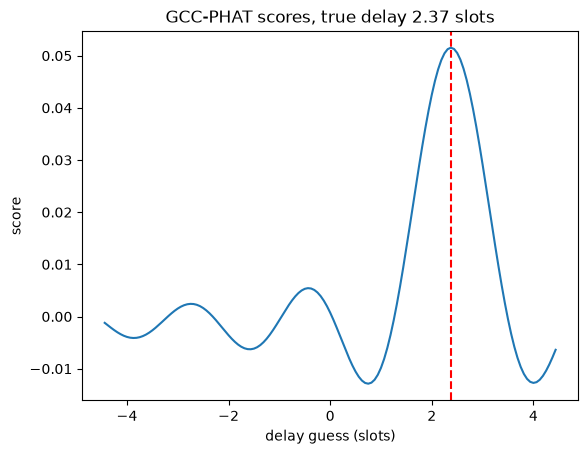

peak at 2.375


In [3]:
x, y = make_delayed_pair(2.37, config.BLOCK_N, snr_db=20)
cc, lags = gcc_phat(x, y)
plt.plot(lags, cc)
plt.axvline(2.37, color="red", linestyle="--")
plt.xlabel("delay guess (slots)")
plt.ylabel("score")
plt.title("GCC-PHAT scores, true delay 2.37 slots")
plt.show()
print("peak at", lags[np.argmax(cc)])